# Does closure before emergence replicate on MeSH? A walkthrough of experiment 4's recorded results

This notebook covers **experiment 4** (artifact `art_yWUkgWWKyq_h`, iteration 2). It re-runs the precursor event study
on a second, independent population: **191 new biomedical MeSH concepts**. The question comes from RQ1: before a concept
emerges, does its co-word neighbourhood show a structural signature? The main pool (experiment 3, `art_mbFjmo5rbbf8`)
had found **lower** closure before sustained uptake (E_up: S = -0.837, Holm p = 0.003). The pre-registration had
predicted **higher** closure.

> **What this notebook is and is not.** The experiment's `method.py`, its yearly co-word snapshots and its result files
> (`replication_verdict.json`, `rq1_patterns.csv`, `rq1_prediction.csv`) were not available when this demo was built.
> So it does **not** re-run the event study. It loads the experiment's **recorded results**, copied verbatim from the
> run record (`run_report.yaml`, `iteration_records.yaml`) into `mini_demo_data.json` with a source for each block. It
> then re-derives the numbers that *can* be derived from them:
> 1. which closure effects exclude zero,
> 2. the inverse-variance-weighted (IVW) pooled E_up estimate across the two populations, with Cochran's Q,
> 3. sign consistency across emergence labels,
> 4. the main-vs-MeSH pattern contrasts,
> 5. whether precursors add predictive value,
> 6. decision rule (c), evaluated in code.

**Emergence labels used below.**
- `PRIMARY` / `E`: the primary strength-percentile label.
- `E_alt`: a pool-only percentile label.
- `SENS1`: the MeSH sensitivity label.
- `E_up`: sustained uptake only, aligned with the main pool's operationalisation.
- `E_vol`, `E_cent`: volume- and centrality-based labels.

The closure effect `D` (MeSH) and `S` (main pool) is the pre-onset difference in log-ratio closure between emerging
concepts and matched controls. A negative value means emerging concepts sit in *more open* neighbourhoods.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

In [2]:
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-2/experiment-4/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL, timeout=15) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

data = load_data()
print(data["metadata"]["artifact_name"])
print("content:", data["metadata"]["content_type"])

gen_art_experiment_4: precursor replication on the MeSH population (RQ1, iteration 2)
content: recorded results (not raw data)


## Configuration

- `Z95`: the normal quantile used to turn a recorded 95% CI back into a standard error (SE = CI width / (2 × 1.96)).
  This treats the recorded CIs as symmetric normal intervals. Section 2 shows that this is only approximate, and section
  3 checks that it still reproduces the recorded IVW numbers.
- `ALPHA`: the significance level for the decision-rule checks.

In [4]:
Z95 = 1.959964   # 95% normal quantile
ALPHA = 0.05

## 1. The MeSH population

The 191 concepts are new MeSH descriptors, established mainly 2006-2016, and pass a provenance filter and a PubMed
novelty pre-screen. They come from dataset `art_HGiVAYhqO-6q`. Two recorded caveats limit how strong this replication
can be. Only about 25% of new descriptors are genuinely new concepts. And 178 of the 191 concepts have PubMed-indexed
works only.

In [5]:
pop = data["population"]
print("selection flow:", " -> ".join(f"{k} {v:,}" for k, v in pop["selection_flow"].items()))
print("by window:", pop["by_window"])
branches = pd.DataFrame(pop["by_branch_group"])
assert branches["count"].sum() == pop["n_concepts"]
print(branches.to_string(index=False))
for c in pop["caveats"]:
    print("caveat:", c)

selection flow: descriptors 28,472 -> topical 5,201 -> after_provenance_filter 3,430 -> passing_pubmed_prescreen 283 -> final 191
by window: {'core_2006_2016': 99, 'widening_2004_2005': 14, 'widening_2017_2018': 78}
                                     group  count
                   D (Chemicals and drugs)     62
                  A+B (Anatomy, Organisms)     47
   E (Analytical, diagnostic, therapeutic)     32
                              C (Diseases)     22
F+H-N (Psychiatry, Health services, misc.)     17
               G (Phenomena and processes)     11
caveat: Only about 25% of new MeSH descriptors are genuinely new concepts (the rest are reclassifications or splits).
caveat: Only 13 of 191 concepts have their full non-PubMed works paged; 178 have PubMed-indexed works only.


## 2. Closure effects on MeSH: which exclude zero?

These are Table 12 of the run report. For each row we recover an approximate SE from the CI and compute an unadjusted
two-sided normal p-value. The recorded p-value is **Holm-adjusted**. If the CIs were symmetric Wald intervals, every
Holm p would be at least as large as the CI-derived raw p. The last column tests that.

In [6]:
def se_from_ci(lo, hi):
    return (hi - lo) / (2 * Z95)

def p_two_sided(est, se):
    return math.erfc(abs(est / se) / math.sqrt(2))

ce = pd.DataFrame(data["closure_effects_mesh"]["rows"])
ce["se_from_ci"] = se_from_ci(ce["ci_low"], ce["ci_high"])
ce["raw_p_from_ci"] = [p_two_sided(d, s) for d, s in zip(ce["D"], ce["se_from_ci"])]
ce["ci_excludes_0"] = (ce["ci_high"] < 0) | (ce["ci_low"] > 0)
ce["holm_p>=raw_p (Wald check)"] = ce["holm_p"] >= ce["raw_p_from_ci"] - 1e-3
print(ce.round(3).to_string(index=False))

  label  n_eff      D  ci_low  ci_high  holm_p  se_from_ci  raw_p_from_ci  ci_excludes_0  holm_p>=raw_p (Wald check)
PRIMARY     15 -0.086  -0.511    0.402   0.677       0.233          0.712          False                       False
  SENS1     29 -0.419  -0.740   -0.115   0.039       0.159          0.009           True                        True
   E_up     51 -0.185  -0.498    0.108   0.210       0.155          0.231          False                       False


**Consistency check.** For `PRIMARY` and `E_up` the recorded Holm p (0.677, 0.21) is *smaller* than the CI-derived raw
p (0.712, 0.231). The recorded CIs are therefore probably not symmetric Wald intervals. They are more likely bootstrap
or permutation intervals from the event study. The CI-derived SEs used below are approximations. Section 3 shows they
still reproduce the recorded pooled numbers.

**Reading.** All three MeSH closure estimates are negative, the same direction as the main pool. Only `SENS1`
(n_eff = 29) has a CI that excludes zero, at Holm p = 0.039. The aligned `E_up` row, the one directly comparable to the
main-pool result, is about a fifth of the main-pool effect and its CI includes zero.

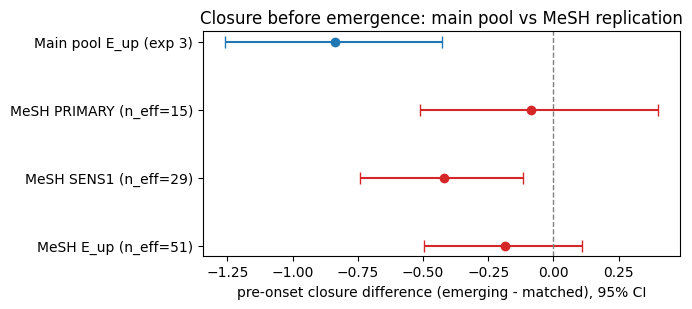

In [7]:
ref = data["main_pool_reference"]
fig, ax = plt.subplots(figsize=(7, 3.2))
rows = [("Main pool E_up (exp 3)", ref["S"], ref["ci_low"], ref["ci_high"])] + \
       [(f"MeSH {r.label} (n_eff={r.n_eff})", r.D, r.ci_low, r.ci_high) for r in ce.itertuples()]
for i, (name, est, lo, hi) in enumerate(rows):
    color = "#1f77b4" if i == 0 else "#d62728"
    ax.errorbar(est, i, xerr=[[est - lo], [hi - est]], fmt="o", color=color, capsize=4)
ax.axvline(0, color="grey", lw=1, ls="--")
ax.set_yticks(range(len(rows)), [r[0] for r in rows])
ax.invert_yaxis()
ax.set_xlabel("pre-onset closure difference (emerging - matched), 95% CI")
ax.set_title("Closure before emergence: main pool vs MeSH replication")
plt.tight_layout(); plt.show()

## 3. Re-deriving the pooled E_up estimate

The run report records an IVW pooled E_up closure estimate of **-0.41 (SE 0.125)** with heterogeneity **Q = 6.16**, but
not how it was computed. Here we recompute it from the two E_up rows alone, the main pool (n = 21) and MeSH (n_eff = 51),
using fixed-effect inverse-variance weights:

$\hat\theta = \frac{\sum_i w_i \theta_i}{\sum_i w_i},\quad w_i = 1/SE_i^2,\quad SE(\hat\theta) = 1/\sqrt{\sum_i w_i},\quad Q = \sum_i w_i(\theta_i - \hat\theta)^2$

In [8]:
def ivw(estimates, ses):
    est, se = np.asarray(estimates, float), np.asarray(ses, float)
    w = 1 / se**2
    pooled = (w * est).sum() / w.sum()
    pooled_se = 1 / math.sqrt(w.sum())
    Q = float((w * (est - pooled) ** 2).sum())
    df = len(est) - 1
    I2 = max(0.0, (Q - df) / Q) if Q > 0 else 0.0
    return pooled, pooled_se, Q, I2

mesh_eup = ce.set_index("label").loc["E_up"]
theta = [ref["S"], mesh_eup["D"]]
ses = [se_from_ci(ref["ci_low"], ref["ci_high"]), mesh_eup["se_from_ci"]]
pooled, pooled_se, Q, I2 = ivw(theta, ses)
p_Q = math.erfc(math.sqrt(Q / 2))   # chi-square survival with df = 1

rec = data["recorded_ivw_pool"]
cmp = pd.DataFrame({
    "recomputed": [pooled, pooled_se, Q],
    "recorded": [rec["estimate"], rec["se"], rec["Q"]],
}, index=["pooled estimate", "SE", "Cochran Q"])
print(cmp.round(3))
print(f"pooled 95% CI: [{pooled - Z95*pooled_se:.3f}, {pooled + Z95*pooled_se:.3f}]")
print(f"heterogeneity: Q = {Q:.2f} on 1 df, p = {p_Q:.4f}, I^2 = {I2:.0%}")
assert abs(pooled - rec["estimate"]) < 0.01 and abs(pooled_se - rec["se"]) < 0.005 and abs(Q - rec["Q"]) < 0.05
print("recorded IVW numbers reproduced from the two E_up rows")

                 recomputed  recorded
pooled estimate      -0.411    -0.410
SE                    0.125     0.125
Cochran Q             6.156     6.160
pooled 95% CI: [-0.656, -0.166]
heterogeneity: Q = 6.16 on 1 df, p = 0.0131, I^2 = 84%
recorded IVW numbers reproduced from the two E_up rows


**Reading.** The recorded pool is reproduced exactly: it is a fixed-effect IVW of the two E_up rows, with SEs recovered
from symmetric CIs. The pooled estimate is clearly negative. But Q = 6.16 on one degree of freedom (p about 0.013,
I² about 84%) says the two populations disagree on the *size* of the effect. A fixed-effect pool therefore overstates
how precise the common estimate is. MeSH does not reproduce the main pool's magnitude.

## 4. Sign consistency across aligned labels

With the main-pool-aligned definitions, the run record gives MeSH point estimates for three labels. Decision rule (c)
requires the precursor to *keep its sign* on MeSH.

In [9]:
signs = pd.DataFrame(data["aligned_closure_signs_mesh"]["rows"])
signs["sign"] = np.sign(signs["D"]).map({-1.0: "-", 1.0: "+", 0.0: "0"})
print(signs.to_string(index=False))
sign_consistent = signs["sign"].nunique() == 1
print("same sign across E, E_alt, E_up on MeSH:", sign_consistent)
print("pre-registered predicted sign for closure:", data["verdict"]["predicted_sign_closure"])

label      D sign
    E  0.487    +
E_alt  0.081    +
 E_up -0.185    -
same sign across E, E_alt, E_up on MeSH: False
pre-registered predicted sign for closure: +


**Reading.** Under `E` and `E_alt` the MeSH closure estimate is *positive* (+0.487, +0.081). Only under `E_up` is it
negative. So the direction of the MeSH replication depends on which emergence label is used.

## 5. Trajectory-pattern contrasts: main pool vs MeSH

The run record reports that early bridging is less common on MeSH, and incubation-then-expansion more common. It calls
this "a genuine between-population difference".

early bridging: MeSH 0.59 | main (iter 2) 0.76 | main (iter 3 recompute) 0.70
recorded difference: +0.11 [0.02, 0.20]
  main(iter 2) - MeSH = +0.17  -> matches recorded difference: False
  main(iter 3) - MeSH = +0.11  -> matches recorded difference: True
incubation-then-expansion: MeSH 0.17 vs main 0.00


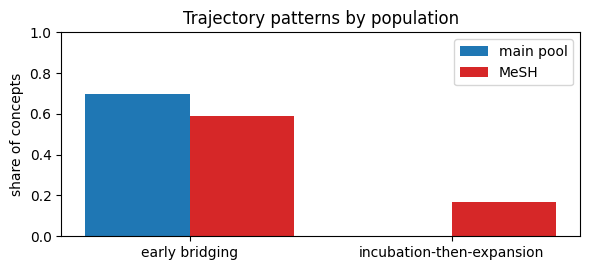

In [10]:
pat = data["patterns"]
eb = pat["early_bridging"]
print(f"early bridging: MeSH {eb['mesh']:.2f} | main (iter 2) {eb['main_iter2']:.2f} | main (iter 3 recompute) {eb['main_iter3']:.2f}")
print(f"recorded difference: +{eb['recorded_difference']:.2f} [{eb['diff_ci_low']:.2f}, {eb['diff_ci_high']:.2f}]")
for name, main in [("iter 2", eb["main_iter2"]), ("iter 3", eb["main_iter3"])]:
    d = main - eb["mesh"]
    print(f"  main({name}) - MeSH = {d:+.2f}  -> matches recorded difference: {abs(d - eb['recorded_difference']) < 0.005}")
ite = pat["incubation_then_expansion"]
print(f"incubation-then-expansion: MeSH {ite['mesh']:.2f} vs main {ite['main']:.2f}")

fig, ax = plt.subplots(figsize=(6, 2.8))
labels = ["early bridging", "incubation-then-expansion"]
x = np.arange(2)
ax.bar(x - 0.2, [eb["main_iter3"], ite["main"]], 0.4, label="main pool", color="#1f77b4")
ax.bar(x + 0.2, [eb["mesh"], ite["mesh"]], 0.4, label="MeSH", color="#d62728")
ax.set_xticks(x, labels); ax.set_ylabel("share of concepts"); ax.set_ylim(0, 1); ax.legend()
ax.set_title("Trajectory patterns by population")
plt.tight_layout(); plt.show()

**Reading.** The recorded difference of +0.11 [0.02, 0.20] matches the **iteration-3** main-pool value (0.70), not the
iteration-2 value (0.76) that appears next to it in the Artifact 10 text. The run report explains the change: the
iteration-2 drop is "fully explained by population-dependent betweenness percentiles". Either way, MeSH concepts bridge
early less often. Some of them incubate before expanding, which no main-pool concept does.

## 6. Do precursors add predictive value on MeSH?

Each row is the change in AUC from adding the structural precursors (closure, accretion, participation) to the
frequency, burst, degree, centrality and entropy baselines.

                                       spec  estimate  ci_low  ci_high            verdict
grouped-CV dAUC (precursors over baselines)     0.002  -0.035    0.035 no detectable gain
                        rolling-origin dAUC     0.041  -0.050    0.098 no detectable gain
                                 E_vol dAUC    -0.009  -0.016   -0.003    precursors HURT
                                E_cent dAUC    -0.036  -0.061   -0.015    precursors HURT


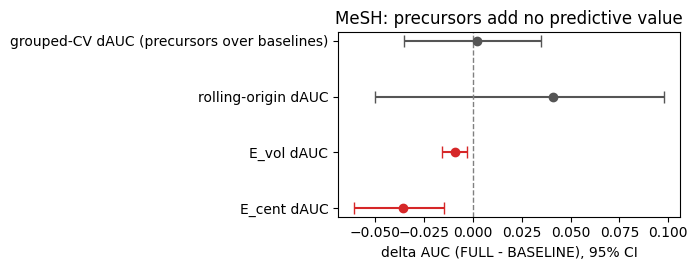

participation LEVEL (descriptive, not predictive): +0.37 SD, BH q <0.001


In [11]:
pr = pd.DataFrame(data["prediction_mesh"]["rows"])
pr["verdict"] = np.where(pr["ci_low"] > 0, "precursors HELP",
                np.where(pr["ci_high"] < 0, "precursors HURT", "no detectable gain"))
print(pr.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 2.8))
for i, r in enumerate(pr.itertuples()):
    ax.errorbar(r.estimate, i, xerr=[[r.estimate - r.ci_low], [r.ci_high - r.estimate]], fmt="o", capsize=4,
                color="#d62728" if r.ci_high < 0 else "#555555")
ax.axvline(0, color="grey", lw=1, ls="--")
ax.set_yticks(range(len(pr)), pr["spec"]); ax.invert_yaxis()
ax.set_xlabel("delta AUC (FULL - BASELINE), 95% CI")
ax.set_title("MeSH: precursors add no predictive value")
plt.tight_layout(); plt.show()

pl = data["participation_level"]
print(f"participation LEVEL (descriptive, not predictive): +{pl['effect_sd']} SD, BH q {pl['bh_q']}")

**Reading.** Precursors add nothing under grouped CV or rolling-origin CV. Under `E_vol` and `E_cent` they make
prediction significantly *worse*. The recorded participation LEVEL difference (+0.37 SD, BH q < 0.001) is a descriptive
difference in level between groups, not a gain in prediction.

## 7. Decision rule (c), evaluated in code

Pre-registered rule (c) reads: *"RQ1 counts as CONFIRMED only if at least one pre-named precursor has an event-study CI
excluding 0 AND a delta-AUC CI excluding 0 on the main screen fold, keeps its sign on MeSH, and holds on the sealed
held-out fold."* The pre-registered sign for closure was **+**. The check below uses closure, the only precursor with a
significant main-pool event-study effect. The main-pool delta-AUC for E_up (-0.010 [-0.045, 0.021], Artifact 9) is
included as a constant from the run record.

In [12]:
MAIN_EUP_DAUC = (-0.010, -0.045, 0.021)   # run_report.yaml, Artifact 9: E_up logit dAUC

checks = {
    "main event-study CI excludes 0": ref["ci_high"] < 0 or ref["ci_low"] > 0,
    "main effect has the predicted + sign": ref["S"] > 0,
    "main delta-AUC CI excludes 0": MAIN_EUP_DAUC[1] > 0 or MAIN_EUP_DAUC[2] < 0,
    "keeps its sign on MeSH across aligned labels": sign_consistent,
    "MeSH aligned E_up CI excludes 0": bool(ce.set_index("label").loc["E_up", "ci_excludes_0"]),
}
for k, v in checks.items():
    print(f"{'PASS' if v else 'FAIL'}  {k}")
rule_c = all(checks.values())
print("\nrule (c):", "MET" if rule_c else "NOT MET", "| recorded:", data["verdict"]["decision_rule_c"])
print("artifact's own verdict:", data["verdict"]["artifact_verdict"])
assert (not rule_c) == (data["verdict"]["decision_rule_c"] == "NOT MET")

PASS  main event-study CI excludes 0
FAIL  main effect has the predicted + sign
FAIL  main delta-AUC CI excludes 0
FAIL  keeps its sign on MeSH across aligned labels
FAIL  MeSH aligned E_up CI excludes 0

rule (c): NOT MET | recorded: NOT MET
artifact's own verdict: directional, not confirmatory


## Summary

- **Direction:** on MeSH the aligned closure effect is negative (E_up D = -0.185), like the main pool. It is not
  significant, and its sign flips to positive under `E` and `E_alt`.
- **Magnitude:** the recorded IVW pool (-0.41, SE 0.125, Q = 6.16) is reproduced exactly from the two E_up rows. The
  heterogeneity is large (I² about 84%), so MeSH does not replicate the main pool's effect size.
- **Prediction:** precursors add no predictive value on MeSH, and under `E_vol` and `E_cent` they hurt.
- **Patterns:** MeSH concepts bridge early less often (0.59 vs 0.70) and sometimes incubate (0.17 vs 0.00).
- **Verdict:** "directional, not confirmatory". Decision rule (c) is **NOT MET**, and the code check above agrees.

The notebook re-derives all of this from recorded summary statistics. Re-running the event study itself would need the
original `method.py` and the MeSH co-word snapshots.